# Student Placement Prediction Using Machine Learning



## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [5]:
df = pd.read_csv('student_placement_dataset.csv')
df.head()

,IQ,CGPA,10th_Marks,12th_Marks,Technical_Skills,Communication_Skills,Placed
0,110,7.13,66.6,86.2,7.0,5.9,1
1,89,6.36,64.0,78.9,8.1,5.8,1
2,116,6.72,77.2,95.6,7.0,5.1,1
3,119,7.93,75.0,49.9,10.0,7.0,1
4,76,7.20,55.1,66.6,9.1,6.7,0


In [6]:
print('Shape:', df.shape)
df.info()
df.describe()

Shape: (1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IQ                    1000 non-null   int64  
 1   CGPA                  1000 non-null   float64
 2   10th_Marks            1000 non-null   float64
 3   12th_Marks            1000 non-null   float64
 4   Technical_Skills      1000 non-null   float64
 5   Communication_Skills  1000 non-null   float64
 6   Placed                1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


,IQ,CGPA,10th_Marks,12th_Marks,Technical_Skills,Communication_Skills,Placed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,104.706000,7.109010,72.330800,69.900400,6.443500,6.371500,0.654000
std,14.445145,1.150509,11.975792,12.408456,1.752144,1.693489,0.475931
min,75.000000,4.500000,40.000000,40.000000,1.000000,1.000000,0.000000
25%,95.000000,6.360000,64.100000,61.075000,5.300000,5.200000,0.000000
50%,105.000000,7.150000,72.400000,69.900000,6.500000,6.400000,1.000000
75%,114.000000,7.890000,80.700000,78.400000,7.600000,7.500000,1.000000
max,145.000000,10.000000,98.000000,98.000000,10.000000,10.000000,1.000000


## 3. Data Cleaning

In [4]:
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
IQ                      0
CGPA                    0
10th_Marks              0
12th_Marks              0
Technical_Skills        0
Communication_Skills    0
Placed                  0
dtype: int64

Duplicate rows: 0


## 4. Exploratory Data Analysis (EDA)

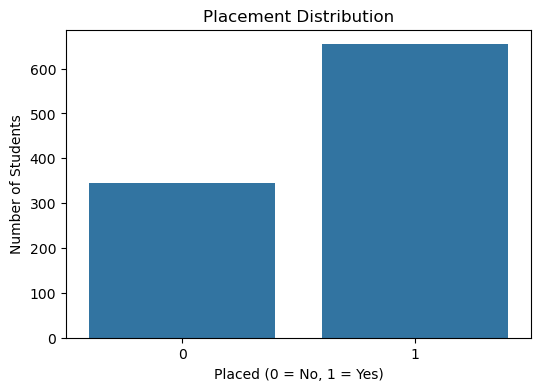

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Placed')
plt.title('Placement Distribution')
plt.xlabel('Placed (0 = No, 1 = Yes)')
plt.ylabel('Number of Students')
plt.show()

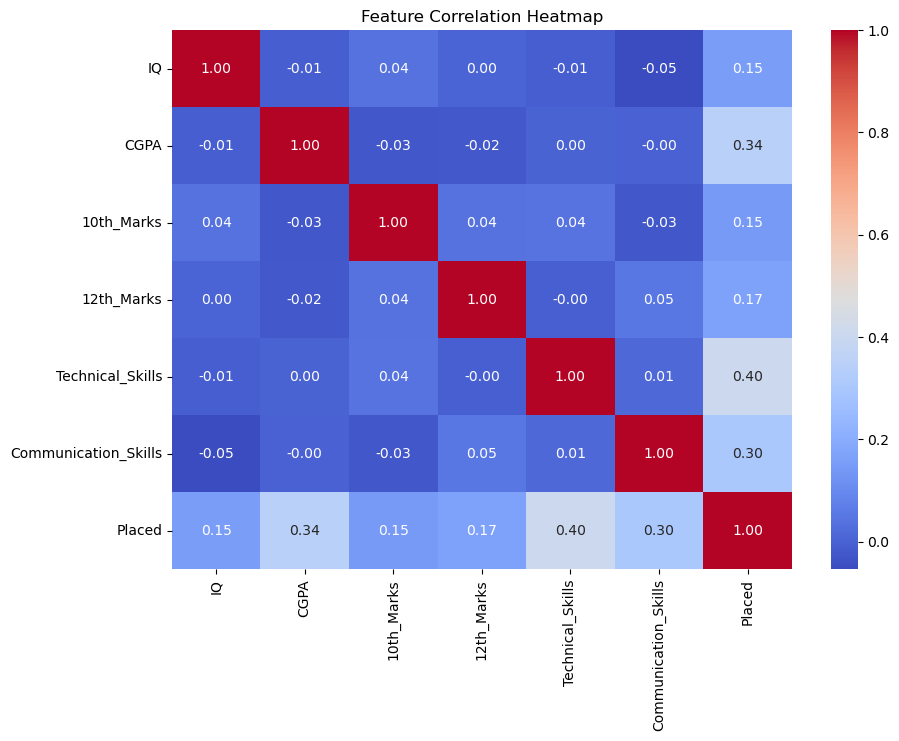

In [6]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

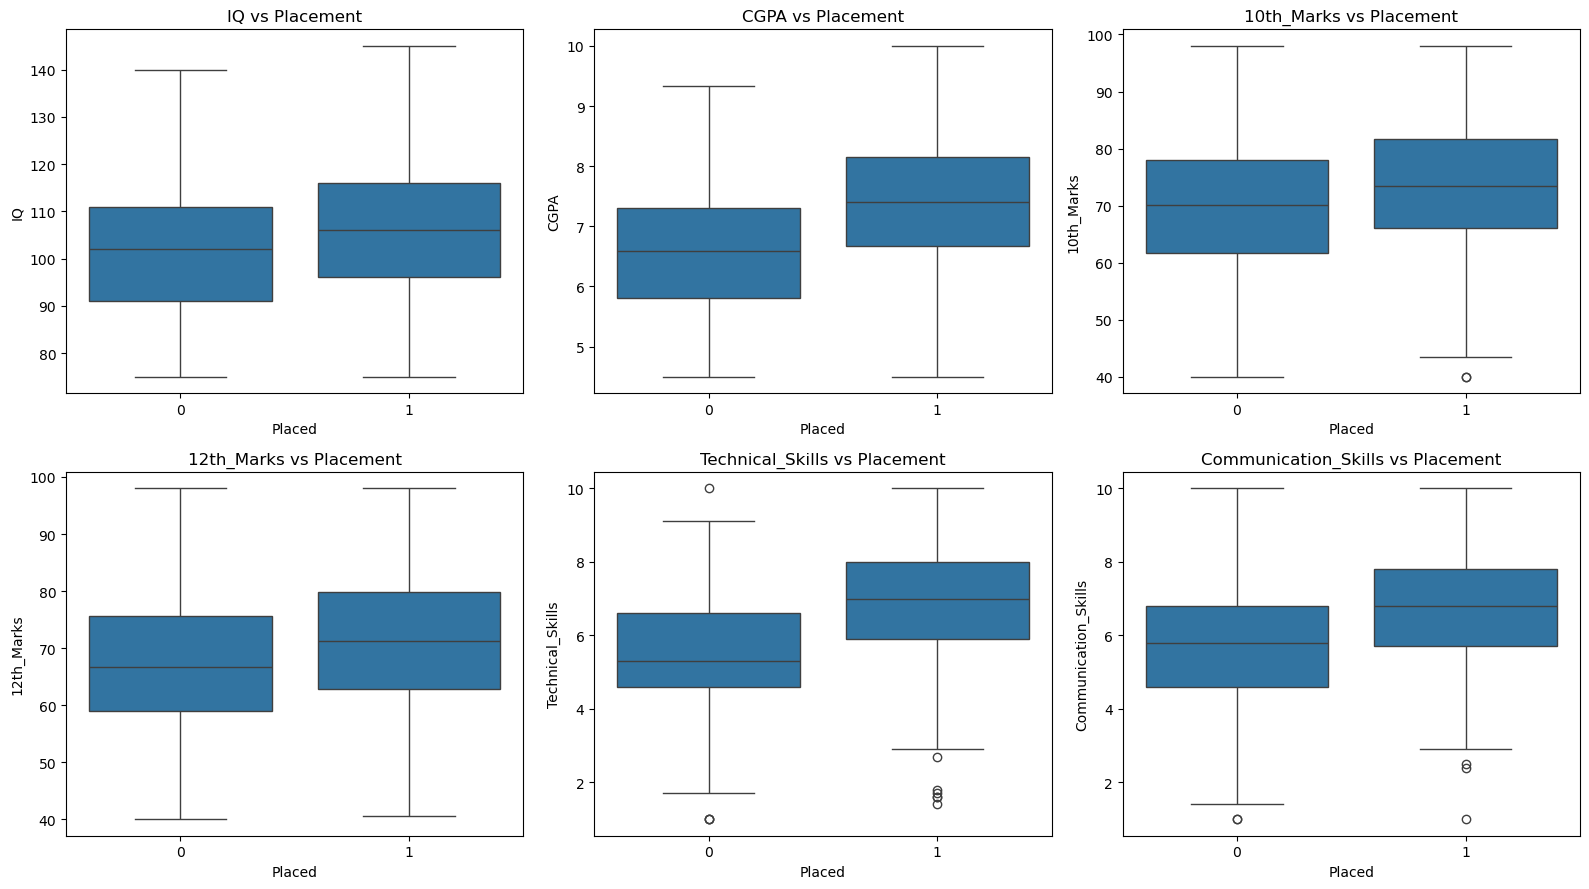

In [10]:
features = ['IQ', 'CGPA', '10th_Marks', '12th_Marks', 'Technical_Skills', 'Communication_Skills']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=df, x='Placed', y=feature, ax=ax)
    ax.set_title(f'{feature} vs Placement')
plt.tight_layout()
plt.show()

## 5. Prepare Data for Machine Learning

In [11]:
X = df[features]
y = df['Placed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 800
Testing samples: 200


## 6. Train Multiple ML Models

In [12]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    # Tree models can use original features; scaling is also harmless here.
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.830,0.888000,0.847328,0.867188,0.922558
2,Random Forest,0.820,0.874016,0.847328,0.860465,0.891913
1,Decision Tree,0.715,0.855769,0.679389,0.757447,0.767010


## 7. Evaluate the Best Model

In [13]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test_scaled)

print('Best Model:', best_model_name)
print('\nClassification Report:\n')
print(classification_report(y_test, best_pred, target_names=['Not Placed', 'Placed']))

Best Model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

  Not Placed       0.73      0.80      0.76        69
      Placed       0.89      0.85      0.87       131

    accuracy                           0.83       200
   macro avg       0.81      0.82      0.82       200
weighted avg       0.83      0.83      0.83       200



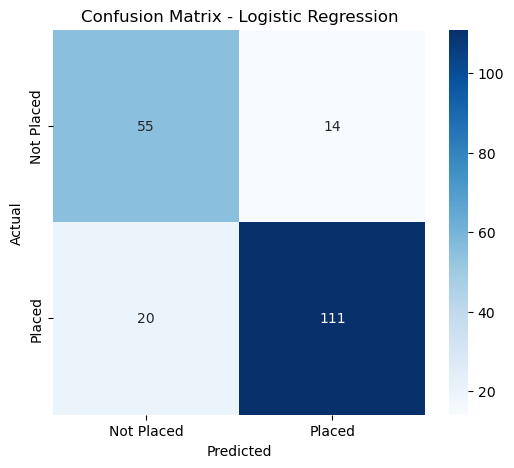

In [11]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 8. Feature Importance / Model Coefficients

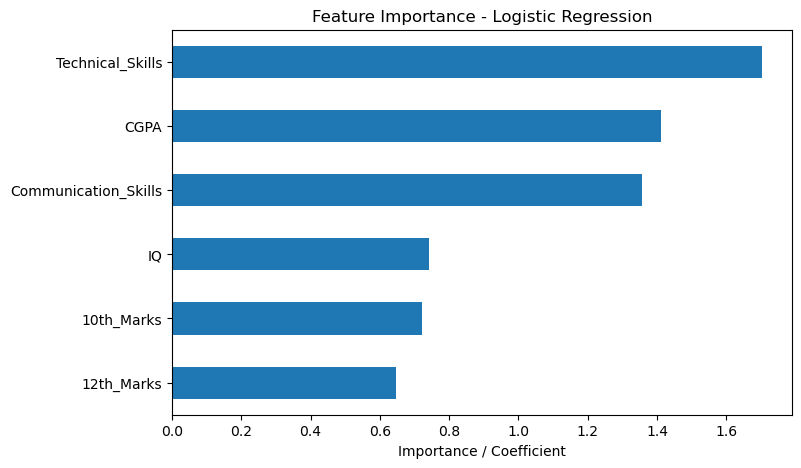

Technical_Skills        1.703408
CGPA                    1.409706
Communication_Skills    1.355237
IQ                      0.740989
10th_Marks              0.722360
12th_Marks              0.648071
dtype: float64


In [14]:
if best_model_name == 'Logistic Regression':
    importance = pd.Series(best_model.coef_[0], index=features).sort_values()
else:
    importance = pd.Series(best_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind='barh')
plt.title(f'Feature Importance - {best_model_name}')
plt.xlabel('Importance / Coefficient')
plt.show()

print(importance.sort_values(ascending=False))

## 9. Predict a New Student

In [16]:
new_student = pd.DataFrame([{
    'IQ': 115,
    'CGPA': 8.2,
    '10th_Marks': 82,
    '12th_Marks': 85,
    'Technical_Skills': 8,
    'Communication_Skills': 7
}])

new_student_scaled = scaler.transform(new_student[features])
prediction = best_model.predict(new_student_scaled)[0]
probability = best_model.predict_proba(new_student_scaled)[0, 1] * 100

print('Placement Probability:', round(probability, 2), '%')
print('Prediction:', 'PLACED' if prediction == 1 else 'NOT PLACED')

Placement Probability: 99.86 %
Prediction: PLACED


In [17]:
import joblib

# Save model
joblib.dump(best_model, "placement_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
